In [1]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/shashank_paper_2/Hindi/Hindi_Depression.csv')

In [2]:
data.head()

,S. No.,text,label
0,0,मेरी सबसे बड़ी समस्या हर चीज़ पर बहुत ज़्यादा ...,1
1,1,सबसे बुरा दुःख वह दुःख है जिसे आपने स्वयं छिपा...,1
2,2,मैं पहले से ही जानता हूं कि मैं काफी अच्छा नही...,1
3,3,"मैं अब पहले जैसा नहीं रहा। मैं मानता हूँ, बहुत...",1
4,4,"मेरे मन में बहुत कुछ चल रहा है, लेकिन मैं अंत ...",1


In [3]:
data_text = data['text']
data_label = data['label']

In [4]:
 import numpy as np
 from sklearn.model_selection import train_test_split
 train, test, labels_train, labels_test = train_test_split(data_text, data_label, test_size=0.25, random_state=42 )

In [5]:
train.head()

3528     आप खुश दिखते हैं लेकिन आप खुश महसूस नहीं करते ...
4040     आपकी पसंद आपकी आशाओं को प्रतिबिंबित करे, आपके ...
11794    ट्रम्प 'उन सभी चीजों का मूर्त रूप हैं जिन्हें ...
447                  कोई नहीं, मैं मर ही जाऊँ तो बेहतर हूँ
4580     जहां से मैं हूं, वहां वे आपके सिर को तब तक पीट...
Name: text, dtype: object

In [6]:
import numpy as np
from tensorflow.keras.utils import to_categorical
#classes_list = ["ham","spam"]
#label_index = class_label.apply(classes_list.index)
label_train = to_categorical(np.asarray(labels_train))
label_test = to_categorical(np.asarray(labels_test))

In [7]:
label_train

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]], dtype=float32)

In [8]:
from keras.preprocessing.text import Tokenizer
tk=Tokenizer(filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True, split=" ")
tk.fit_on_texts(train)
index=tk.word_index
print(index)
x = tk.texts_to_sequences(train)
x1 = tk.texts_to_sequences(test)
print (x)
vocab_size = len(index)
word_index = tk.word_index

{'है': 1, 'के': 2, 'में': 3, 'नहीं': 4, 'की': 5, 'से': 6, 'मैं': 7, 'को': 8, 'हैं': 9, 'कि': 10, 'का': 11, 'है।': 12, 'और': 13, 'एक': 14, 'लिए': 15, 'आप': 16, 'ने': 17, 'पर': 18, 'मुझे': 19, 'यह': 20, 'भी': 21, 'कर': 22, 'कभी': 23, 'हूं': 24, 'हो': 25, 'जो': 26, 'तो': 27, 'सामान्य': 28, 'हैं।': 29, 'करने': 30, 'कोई': 31, 'कुछ': 32, 'ही': 33, 'जीवन': 34, 'अपने': 35, 'जब': 36, 'लेकिन': 37, 'किसी': 38, 'बहुत': 39, 'आपको': 40, 'रहा': 41, 'वह': 42, 'सबसे': 43, 'क्या': 44, 'करता': 45, 'किया': 46, 'हूँ': 47, 'करना': 48, 'करते': 49, 'होता': 50, 'गया': 51, 'साथ': 52, 'न': 53, 'मेरे': 54, 'सकता': 55, 'अधिक': 56, 'हूं।': 57, 'बारे': 58, 'महसूस': 59, 'ट्रम्प': 60, 'हम': 61, 'हर': 62, 'लोग': 63, 'लोगों': 64, 'अपनी': 65, 'तरह': 66, 'दिया': 67, 'बात': 68, 'वे': 69, 'प्यार': 70, 'व्यक्ति': 71, 'तक': 72, 'इस': 73, 'आपके': 74, 'होने': 75, 'चाहता': 76, 'समय': 77, 'सकते': 78, 'रहे': 79, 'हूँ।': 80, 'हमेशा': 81, 'बस': 82, 'मेरी': 83, 'था': 84, 'अब': 85, 'मेरा': 86, 'तुम': 87, 'क्योंकि': 88, 'ऐसा': 89, 'दिन

In [9]:
print(vocab_size)

11468


In [10]:
from keras.preprocessing.sequence import pad_sequences
embedding_vecor_length =32
padded_docs_train = pad_sequences(x, maxlen=embedding_vecor_length, padding='post')
padded_docs_test = pad_sequences(x1, maxlen=embedding_vecor_length, padding='post')


In [11]:
#load pre-trained embedding:
embeddings_index = {}
f = open('/content/drive/My Drive/LSTM_Attention_on_sarcasm_dataset/glove.twitter.27B/glove.twitter.27B.100d.txt', encoding="utf8")
for line in f:
    values = line.split()#This splits each values in a  line with spaces
    word = values[0] # This store the first values which is the word in english
    coefs = np.asarray(values[1:], dtype='float32') # This converts all splitted values from 1 to last(expect first word) into an array
    embeddings_index[word] = coefs # english word = array of numerical values
f.close()
print('Total %s word vectors in Glove 6B 100d.' % len(embeddings_index))

Total 1193514 word vectors in Glove 6B 100d.


In [12]:
# Initialize the weight for each word for the embedding layer. Words not present
# in the dictionary initialized by random value
EMBEDDING_DIM = 100
embedding_matrix = np.random.random((len(word_index) + 1, EMBEDDING_DIM))
#embedding_matrix = (16433, 100) NOTE: It is from uniques words in our tweets
for word, i in word_index.items(): # Selecting word from our tweet unique words list for changing with the values from glove
    embedding_vector = embeddings_index.get(word) # Finding our tweet words in glove and taking its array of 100 values
    if embedding_vector is not None:
#words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 32, 100)           1146900   
                                                                 
 conv1d (Conv1D)             (None, 30, 128)           38528     
                                                                 
 max_pooling1d (MaxPooling1  (None, 6, 128)            0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 768)               0         
                                                                 
 dense (Dense)               (None, 256)               196864    
                                                                 
 dense_1 (Dense)             (None, 2)                 514       
                                                        

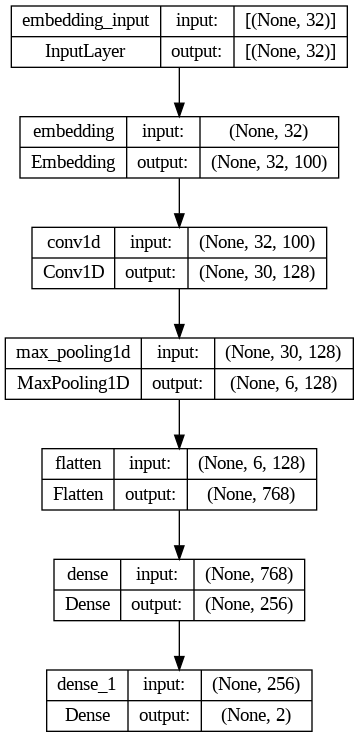

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Embedding
from keras.layers import Conv1D, GlobalMaxPooling1D, MaxPooling1D
from tensorflow.keras.utils import plot_model
model = Sequential()
model.add(Embedding(input_dim = vocab_size + 1, output_dim = 100, weights=[embedding_matrix], input_length=embedding_vecor_length, trainable=False))
model.add(Conv1D(filters = 128,kernel_size=3, activation='relu'))
model.add(MaxPooling1D(5))
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dense(2, activation = 'softmax'))
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
model.summary()
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


In [14]:
model.fit(padded_docs_train, label_train, validation_data = (padded_docs_test, label_test),
          epochs=100,batch_size=100, verbose=2)

Epoch 1/100
91/91 - 6s - loss: 0.5022 - accuracy: 0.7445 - val_loss: 0.4641 - val_accuracy: 0.7673 - 6s/epoch - 62ms/step
Epoch 2/100
91/91 - 0s - loss: 0.4048 - accuracy: 0.8055 - val_loss: 0.4473 - val_accuracy: 0.7809 - 449ms/epoch - 5ms/step
Epoch 3/100
91/91 - 0s - loss: 0.3427 - accuracy: 0.8434 - val_loss: 0.4900 - val_accuracy: 0.7842 - 370ms/epoch - 4ms/step
Epoch 4/100
91/91 - 0s - loss: 0.2919 - accuracy: 0.8722 - val_loss: 0.3863 - val_accuracy: 0.8201 - 342ms/epoch - 4ms/step
Epoch 5/100
91/91 - 0s - loss: 0.2432 - accuracy: 0.8954 - val_loss: 0.4684 - val_accuracy: 0.7866 - 457ms/epoch - 5ms/step
Epoch 6/100
91/91 - 0s - loss: 0.1993 - accuracy: 0.9190 - val_loss: 0.4020 - val_accuracy: 0.8285 - 351ms/epoch - 4ms/step
Epoch 7/100
91/91 - 0s - loss: 0.1517 - accuracy: 0.9411 - val_loss: 0.4651 - val_accuracy: 0.8265 - 338ms/epoch - 4ms/step
Epoch 8/100
91/91 - 0s - loss: 0.1176 - accuracy: 0.9571 - val_loss: 0.5226 - val_accuracy: 0.8288 - 349ms/epoch - 4ms/step
Epoch 9/10

In [15]:
predictions_test_cnn = model.predict(padded_docs_test)
predictions_testcnn1 = np.zeros_like(predictions_test_cnn)
predictions_testcnn1[np.arange(len(predictions_test_cnn)), predictions_test_cnn.argmax(1)] = 1
from sklearn.metrics import classification_report
print(classification_report(label_test,predictions_testcnn1))


94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1811
           1       0.78      0.77      0.78      1197

   micro avg       0.82      0.82      0.82      3008
   macro avg       0.81      0.81      0.81      3008
weighted avg       0.82      0.82      0.82      3008
 samples avg       0.82      0.82      0.82      3008



In [ ]:
import time
start_time = time.time()
predictions_test_cnn = model.predict(padded_docs_test)
print("--- %s seconds ---" % (time.time() - start_time))

--- 0.3469421863555908 seconds ---
